# IBM Telco Customer Churn Analysis
**Author:** Ashish  
**Dataset:** `data/WA_Fn-UseC_-Telco-Customer-Churn.csv`

Covers: data loading & cleaning → KPI summary → driver analysis plot → Random Forest model → evaluation.

## 1. Imports & Setup

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score
)
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

# Output directories
os.makedirs('report_images', exist_ok=True)
os.makedirs('model', exist_ok=True)

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Cleaning

In [3]:
# --- Fix TotalCharges: coerce whitespace-only strings to NaN, then fill with MonthlyCharges ---
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
missing_tc = df['TotalCharges'].isna().sum()
print(f'TotalCharges missing values (whitespace rows): {missing_tc}')
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)

# --- Drop customerID (non-predictive identifier) ---
df.drop(columns=['customerID'], inplace=True)

# --- Encode target: Churn  Yes→1, No→0 ---
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'Shape after cleaning: {df.shape}')
print(f'Churn dtype: {df["Churn"].dtype}')
df.info()

TotalCharges missing values (whitespace rows): 11
Shape after cleaning: (7043, 20)
Churn dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15

## 4. KPI Summary

In [4]:
churn_rate = df['Churn'].mean() * 100
avg_monthly = df['MonthlyCharges'].mean()
avg_total   = df['TotalCharges'].mean()

print('=' * 45)
print(f'  Overall Churn Rate        : {churn_rate:.2f}%')
print(f'  Avg Monthly Charges (all) : ${avg_monthly:.2f}')
print(f'  Avg Total Charges  (all)  : ${avg_total:.2f}')
print('=' * 45)

# Avg spend by churn status
spend_by_churn = df.groupby('Churn')[['MonthlyCharges', 'TotalCharges']].mean().round(2)
spend_by_churn.index = spend_by_churn.index.map({0: 'No Churn', 1: 'Churned'})
print('\nAverage Spend by Churn Status:')
print(spend_by_churn)

  Overall Churn Rate        : 26.54%
  Avg Monthly Charges (all) : $64.76
  Avg Total Charges  (all)  : $2283.30

Average Spend by Churn Status:
          MonthlyCharges  TotalCharges
Churn                                 
No Churn           61.27       2555.34
Churned            74.44       1531.80


## 5. KPI & Driver Analysis Plot

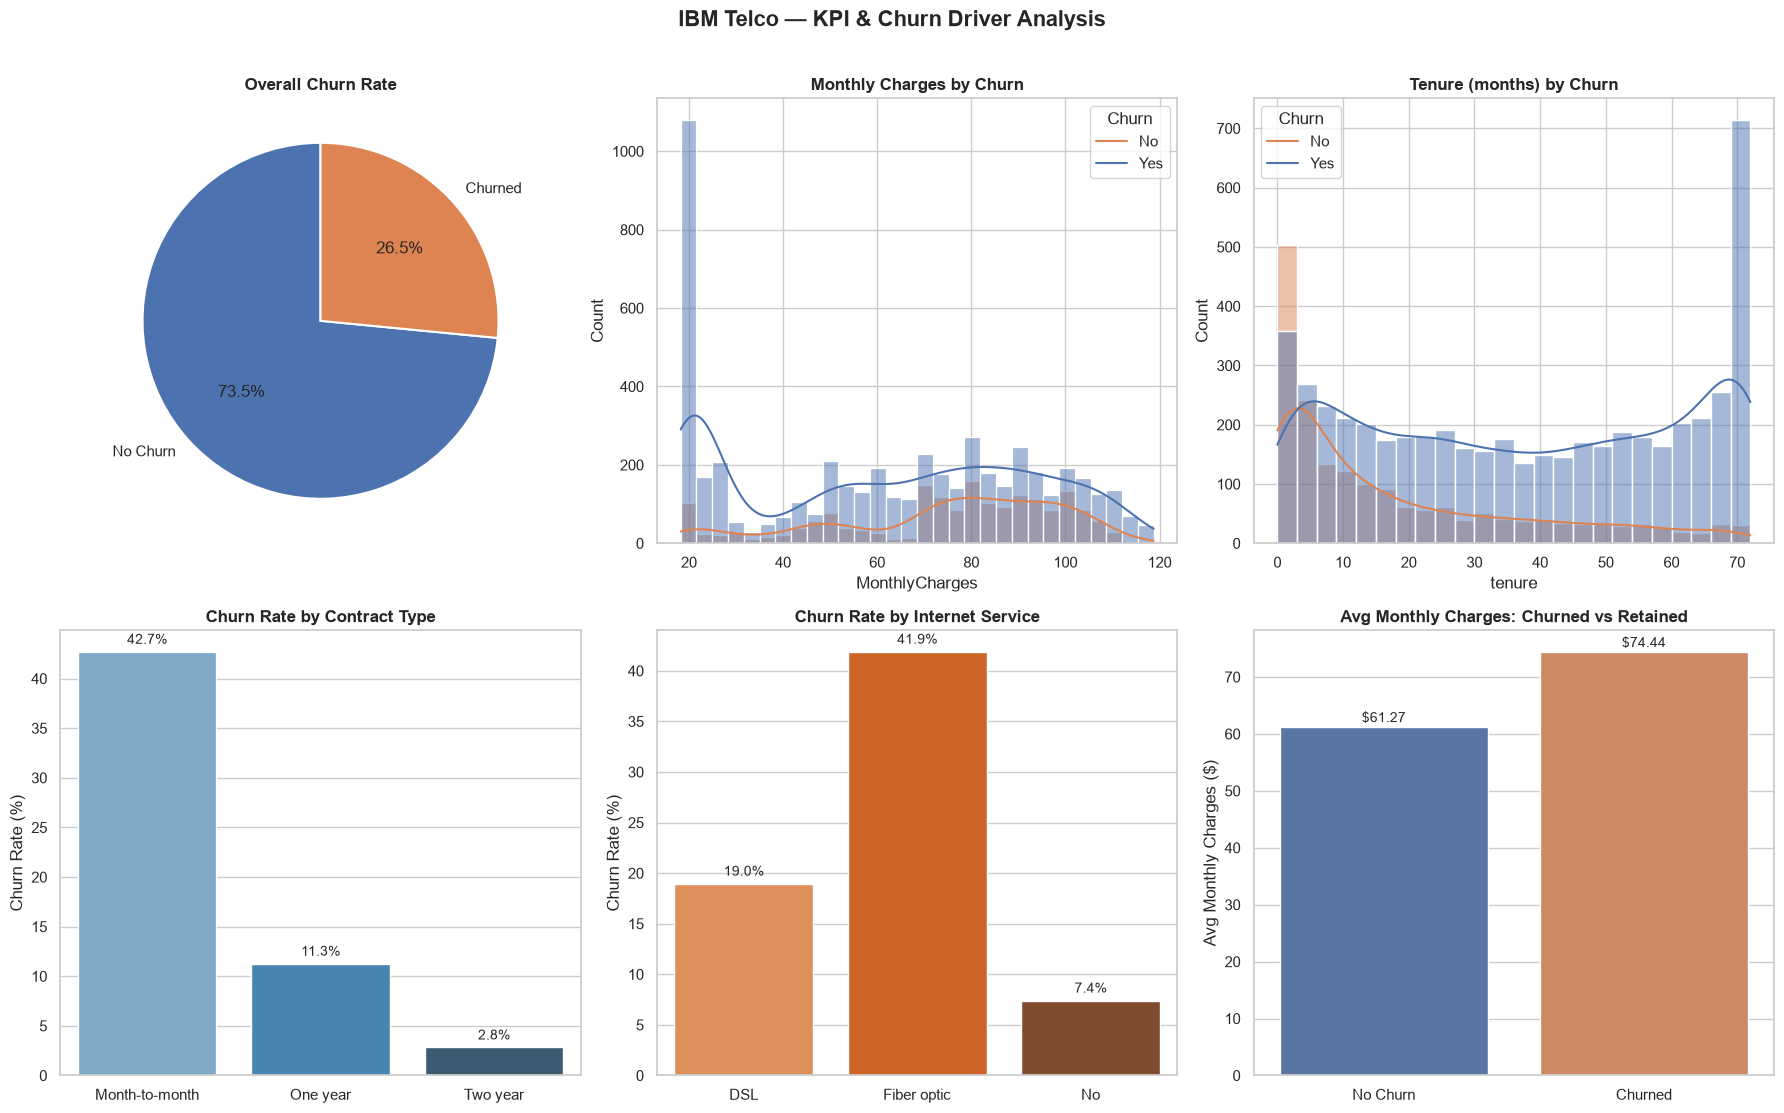

Driver analysis plot saved → report_images/kpi_and_driver_analysis.png


In [5]:
sns.set_theme(style='whitegrid', palette='muted')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('IBM Telco — KPI & Churn Driver Analysis', fontsize=16, fontweight='bold', y=1.01)

# -- Plot 1: Churn distribution (pie) --
ax = axes[0, 0]
churn_counts = df['Churn'].value_counts()
ax.pie(
    churn_counts,
    labels=['No Churn', 'Churned'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('Overall Churn Rate', fontweight='bold')

# -- Plot 2: Monthly Charges distribution by churn --
ax = axes[0, 1]
sns.histplot(
    data=df, x='MonthlyCharges', hue='Churn',
    bins=30, kde=True, ax=ax,
    palette={0: '#4C72B0', 1: '#DD8452'}
)
ax.set_title('Monthly Charges by Churn', fontweight='bold')
ax.legend(title='Churn', labels=['No', 'Yes'])

# -- Plot 3: Tenure distribution by churn --
ax = axes[0, 2]
sns.histplot(
    data=df, x='tenure', hue='Churn',
    bins=24, kde=True, ax=ax,
    palette={0: '#4C72B0', 1: '#DD8452'}
)
ax.set_title('Tenure (months) by Churn', fontweight='bold')
ax.legend(title='Churn', labels=['No', 'Yes'])

# -- Plot 4: Churn rate by Contract type --
ax = axes[1, 0]
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn'] = contract_churn['Churn'] * 100
sns.barplot(data=contract_churn, x='Contract', y='Churn', ax=ax, palette='Blues_d')
ax.set_title('Churn Rate by Contract Type', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('')
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=10
    )

# -- Plot 5: Churn rate by Internet Service --
ax = axes[1, 1]
internet_churn = df.groupby('InternetService')['Churn'].mean().reset_index()
internet_churn['Churn'] = internet_churn['Churn'] * 100
sns.barplot(data=internet_churn, x='InternetService', y='Churn', ax=ax, palette='Oranges_d')
ax.set_title('Churn Rate by Internet Service', fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('')
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center', va='bottom', fontsize=10
    )

# -- Plot 6: Average Monthly Charges — churned vs retained --
ax = axes[1, 2]
avg_spend = df.groupby('Churn')['MonthlyCharges'].mean().reset_index()
avg_spend['Label'] = avg_spend['Churn'].map({0: 'No Churn', 1: 'Churned'})
sns.barplot(data=avg_spend, x='Label', y='MonthlyCharges', ax=ax,
            palette={'No Churn': '#4C72B0', 'Churned': '#DD8452'})
ax.set_title('Avg Monthly Charges: Churned vs Retained', fontweight='bold')
ax.set_ylabel('Avg Monthly Charges ($)')
ax.set_xlabel('')
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'${bar.get_height():.2f}',
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
driver_plot_path = 'report_images/kpi_and_driver_analysis.png'
plt.savefig(driver_plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Driver analysis plot saved → {driver_plot_path}')

## 6. Feature Engineering & Encoding

In [6]:
df_model = df.copy()

# Label-encode all remaining object columns
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns: {cat_cols}')

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f'Feature matrix shape : {X.shape}')
print(f'Target distribution  :\n{y.value_counts()}')

Encoding 15 categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Feature matrix shape : (7043, 19)
Target distribution  :
Churn
0    5174
1    1869
Name: count, dtype: int64


## 7. Train / Test Split & Random Forest Training

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Random Forest training complete.')

Train size: 5634  |  Test size: 1409


Random Forest training complete.


## 8. Model Evaluation

In [8]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f'ROC-AUC Score : {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churned']))

ROC-AUC Score : 0.8413

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1035
     Churned       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409



## 9. Confusion Matrix — Save to report_images/

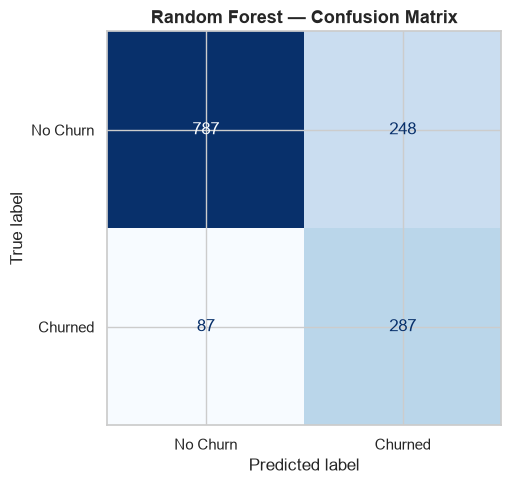

Confusion matrix saved → report_images/confusion_matrix.png


In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churned'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(
    cmap='Blues',
    ax=ax,
    colorbar=False,
    values_format='d'
)
ax.set_title('Random Forest — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()

cm_path = 'report_images/confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Confusion matrix saved → {cm_path}')

## 10. Feature Importance

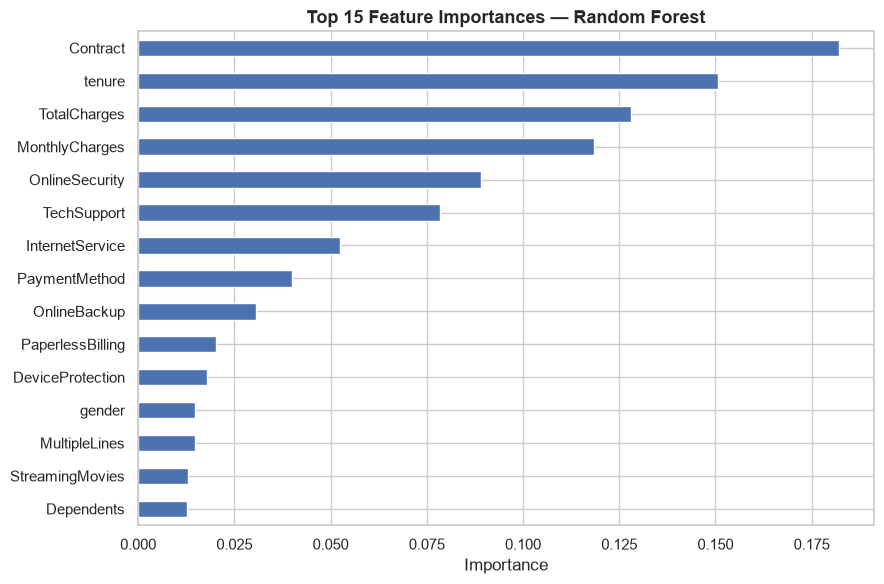

Feature importance plot saved → report_images/feature_importance.png


In [10]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top15    = feat_imp.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('report_images/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance plot saved → report_images/feature_importance.png')

## 11. Save Model

In [11]:
model_path = 'model/churn_model.pkl'
joblib.dump(rf, model_path)
print(f'Model saved → {model_path}')

# Quick sanity check: reload and re-score
reloaded = joblib.load(model_path)
sanity_auc = roc_auc_score(y_test, reloaded.predict_proba(X_test)[:, 1])
print(f'Reloaded model ROC-AUC : {sanity_auc:.4f}  ✓')

Model saved → model/churn_model.pkl
Reloaded model ROC-AUC : 0.8413  ✓
